# S&P 500 and Macroeconomic Indicators Analysis

This project explores the relationship between the S&P 500 index and key macroeconomic indicators such as inflation, interest rates, unemployment, and market volatility.

The goal is to understand how macroeconomic conditions influence stock market performance.

Tools used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Tableau

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets

In this section we load the S&P 500 data along with several macroeconomic indicators.

In [2]:
sp500 = pd.read_csv("../data/raw/sp500_index.csv")
cpi = pd.read_csv("../data/raw/economic_CPI.csv")
rates = pd.read_csv("../data/raw/economic_DGS10.csv")
fed = pd.read_csv("../data/raw/economic_FEDFUNDS.csv")
unrate = pd.read_csv("../data/raw/economic_UNRATE.csv")
vix = pd.read_csv("../data/raw/economic_VIX.csv")

## Initial Data Exploration

We first inspect the datasets to understand their structure and variables.

In [3]:
sp500.head()

,"('date', '')","('close', '^gspc')","('high', '^gspc')","('low', '^gspc')","('open', '^gspc')","('volume', '^gspc')","('ticker', '')"
0,1970-01-02,93.000000,93.540001,91.790001,92.059998,8050000,^GSPC
1,1970-01-05,93.459999,94.250000,92.529999,93.000000,11490000,^GSPC
2,1970-01-06,92.820000,93.809998,92.129997,93.459999,11460000,^GSPC
3,1970-01-07,92.629997,93.379997,91.930000,92.820000,10010000,^GSPC
4,1970-01-08,92.680000,93.470001,91.989998,92.629997,10670000,^GSPC


In [4]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14155 entries, 0 to 14154
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ('date', '')         14155 non-null  object 
 1   ('close', '^gspc')   14155 non-null  float64
 2   ('high', '^gspc')    14155 non-null  float64
 3   ('low', '^gspc')     14155 non-null  float64
 4   ('open', '^gspc')    14155 non-null  float64
 5   ('volume', '^gspc')  14155 non-null  int64  
 6   ('ticker', '')       14155 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 774.2+ KB


In [5]:
sp500.describe()

,"('close', '^gspc')","('high', '^gspc')","('low', '^gspc')","('open', '^gspc')","('volume', '^gspc')"
count,14155.000000,14155.000000,14155.000000,14155.000000,1.415500e+04
mean,1234.154523,1241.038449,1226.285490,1233.901794,1.684735e+09
std,1432.150301,1439.232627,1424.015843,1431.941170,1.932527e+09
min,62.279999,63.230000,60.959999,62.279999,0.000000e+00
25%,162.764999,163.575005,162.099998,162.725006,8.478500e+07
50%,863.159973,871.799988,847.039978,862.820007,5.791800e+08
75%,1460.920044,1470.350037,1451.554993,1460.934998,3.429550e+09
max,6978.600098,7002.279785,6963.459961,7002.000000,1.145623e+10


## Data Cleaning

In this section we prepare the datasets for analysis by converting date columns and ensuring consistent formats.

In [7]:
sp500.columns = [
    "date",
    "close",
    "high",
    "low",
    "open",
    "volume",
    "ticker"
]

In [8]:
sp500["date"] = pd.to_datetime(sp500["date"])

In [9]:
cpi = cpi.rename(columns={"DATE": "date"})
rates = rates.rename(columns={"DATE": "date"})
fed = fed.rename(columns={"DATE": "date"})
unrate = unrate.rename(columns={"DATE": "date"})
vix = vix.rename(columns={"DATE": "date"})

In [10]:
cpi["date"] = pd.to_datetime(cpi["date"])
rates["date"] = pd.to_datetime(rates["date"])
fed["date"] = pd.to_datetime(fed["date"])
unrate["date"] = pd.to_datetime(unrate["date"])
vix["date"] = pd.to_datetime(vix["date"])

In [12]:
print(sp500.head())

        date      close       high        low       open    volume ticker
0 1970-01-02  93.000000  93.540001  91.790001  92.059998   8050000  ^GSPC
1 1970-01-05  93.459999  94.250000  92.529999  93.000000  11490000  ^GSPC
2 1970-01-06  92.820000  93.809998  92.129997  93.459999  11460000  ^GSPC
3 1970-01-07  92.629997  93.379997  91.930000  92.820000  10010000  ^GSPC
4 1970-01-08  92.680000  93.470001  91.989998  92.629997  10670000  ^GSPC


In [13]:
print(cpi.head())

        date  CPIAUCSL
0 1970-01-01      37.9
1 1970-02-01      38.1
2 1970-03-01      38.3
3 1970-04-01      38.5
4 1970-05-01      38.6


## Merge Datasets

In this section we combine the S&P 500 dataset with macroeconomic indicators using the date column.

In [14]:
df = sp500.merge(cpi, on="date", how="left") \
          .merge(rates, on="date", how="left") \
          .merge(fed, on="date", how="left") \
          .merge(unrate, on="date", how="left") \
          .merge(vix, on="date", how="left")

In [26]:
df = df.rename(columns={
    "VIXCLS": "VIX",
    "CPIAUCSL": "CPI"
})

In [27]:
df.head()

,date,close,high,low,open,volume,ticker,CPI,DGS10,FEDFUNDS,UNRATE,VIX,returns
5054,1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000,^GSPC,126.3,7.94,8.45,5.4,17.24,0.017799
5055,1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000,^GSPC,126.3,7.99,8.45,5.4,18.19,-0.002586
5056,1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000,^GSPC,126.3,7.98,8.45,5.4,19.22,-0.008613
5057,1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000,^GSPC,126.3,7.99,8.45,5.4,20.11,-0.009756
5058,1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000,^GSPC,126.3,8.02,8.45,5.4,20.26,0.004514


In [16]:
df = df.fillna(method="ffill")

/var/folders/lp/czhflkl938q1fg_zsvb8qv5r0000gn/T/ipykernel_57848/567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


## Feature Engineering

In this section we create additional variables to analyze market performance.

The main feature we create is the daily return of the S&P 500, which measures the percentage change in the index from one day to the next.

In [17]:
df["returns"] = df["close"].pct_change()

In [18]:
df = df.dropna()

In [19]:
df.head()

,date,close,high,low,open,volume,ticker,CPIAUCSL,DGS10,FEDFUNDS,UNRATE,VIXCLS,returns
5054,1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000,^GSPC,126.3,7.94,8.45,5.4,17.24,0.017799
5055,1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000,^GSPC,126.3,7.99,8.45,5.4,18.19,-0.002586
5056,1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000,^GSPC,126.3,7.98,8.45,5.4,19.22,-0.008613
5057,1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000,^GSPC,126.3,7.99,8.45,5.4,20.11,-0.009756
5058,1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000,^GSPC,126.3,8.02,8.45,5.4,20.26,0.004514


## Exploratory Data Analysis

In this section we explore the behavior of the S&P 500 and its relationship with macroeconomic indicators.

### S&P 500 Index Over Time

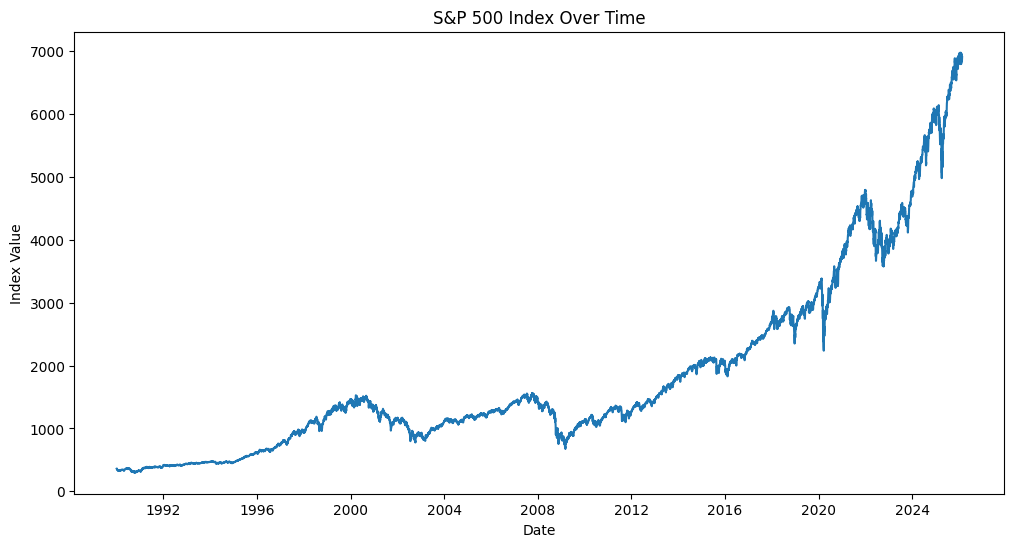

In [28]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["close"])

plt.title("S&P 500 Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

### Distribution of Market Returns

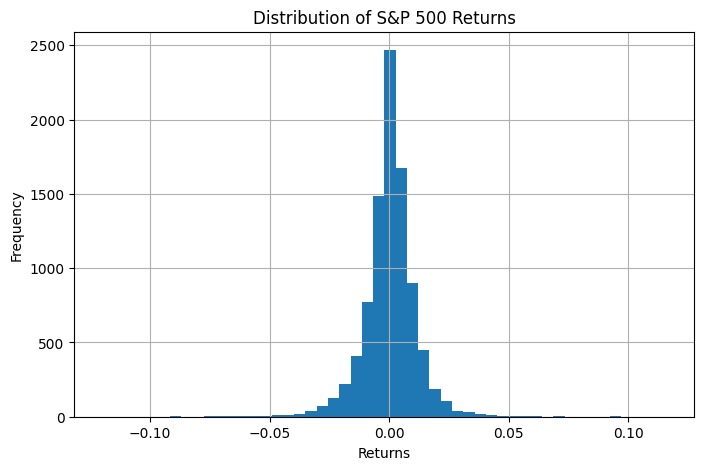

In [29]:
plt.figure(figsize=(8,5))

df["returns"].hist(bins=50)

plt.title("Distribution of S&P 500 Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")

plt.show()

### Correlation Matrix

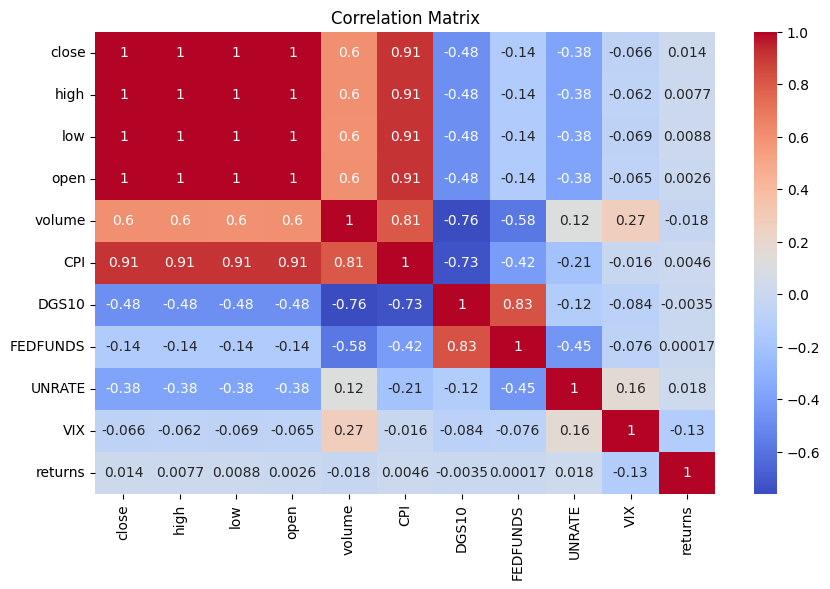

In [30]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

### VIX vs Market Returns

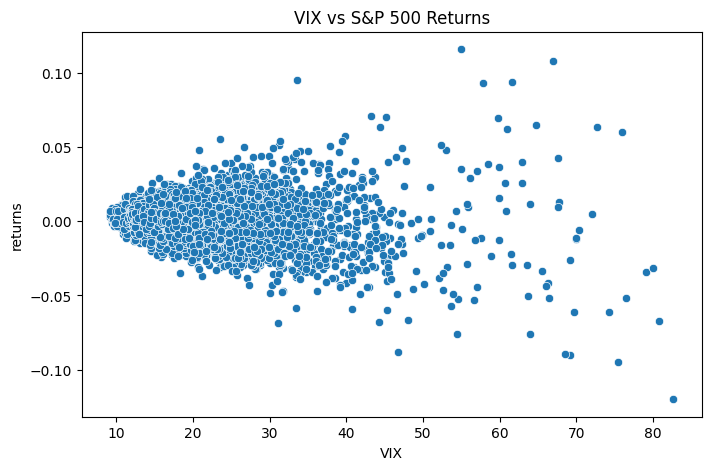

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["VIX"], y=df["returns"])

plt.title("VIX vs S&P 500 Returns")

plt.show()

### Interest Rates vs Market Returns

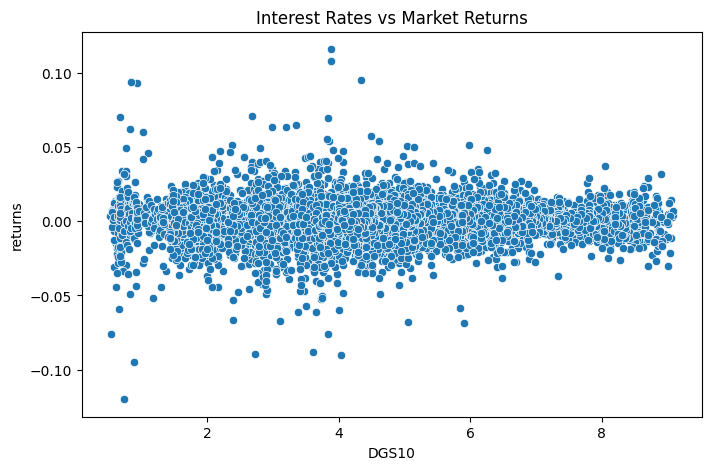

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["DGS10"], y=df["returns"])

plt.title("Interest Rates vs Market Returns")

plt.show()

### Unemployment vs Market Returns

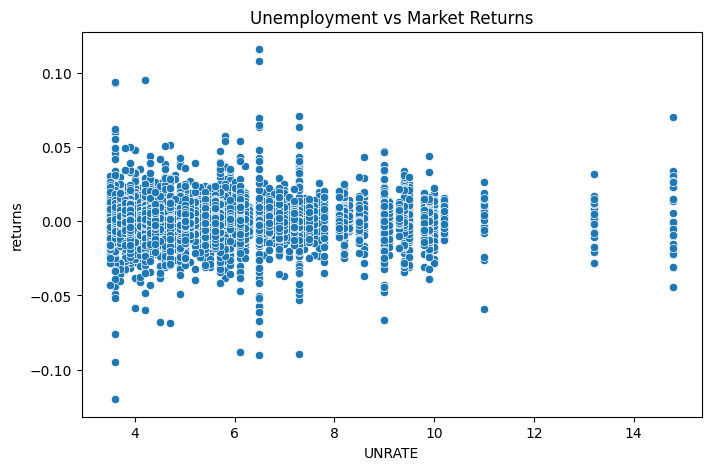

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["UNRATE"], y=df["returns"])

plt.title("Unemployment vs Market Returns")

plt.show()

## Export Dataset for Tableau

The processed dataset is exported for building the Tableau dashboard.

In [34]:
df.to_csv("../data/processed/sp500_macro_dataset.csv", index=False)